
**Objective**

Build a Convolutional Neural Network (ConvNet) using the Keras Sequential API to classify plant leaf images into 38 disease categories.

**Dataset**
**New Plant Diseases Dataset** from Kaggle
- 54,000+ leaf images across 38 classes
- Classes include healthy leaves and various disease types across crops
like tomato, apple, corn, grape, potato and more
- Already split into train and validation sets
- Color JPG images resized to 128×128 for training

**Approach**
- Use the Keras **Sequential API** to build a multi-block ConvNet from scratch
- Apply data augmentation to improve generalisation
- Use BatchNormalization and Dropout to reduce overfitting
- Use EarlyStopping and ReduceLROnPlateau callbacks to manage training

**Learning Objectives**
- How to build and train a ConvNet using the Sequential API
- How the data pipeline works with ImageDataGenerator
- How to interpret training history, confusion matrices and predictions
- The limitations of training from scratch vs transfer learning

In [3]:
# ============================================
# Download Plant Disease Dataset from Kaggle
# ============================================

from google.colab import files

# Upload kaggle.json
files.upload()

# Configure Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Unzip dataset
!unzip -q new-plant-diseases-dataset.zip


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:10<00:00, 22.2MB/s]



In [4]:
import os

for root, dirs, files in os.walk("/content"):
    if "train" in dirs and "valid" in dirs:
        print("Dataset found at:")
        print(root)

Dataset found at:
/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)
Dataset found at:
/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)


In [5]:


# ============================================
# Explore Dataset
# ============================================

import os

TRAIN_DIR = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VAL_DIR = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f"Number of classes: {NUM_CLASSES}")
print(f"First 5 classes: {CLASS_NAMES[:5]}")

total_train = 0

print("\nImages per class:")
for cls in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, cls)
    count = len(os.listdir(class_path))
    total_train += count
    print(f"{cls}: {count}")

print(f"\nTotal training images: {total_train}")

Number of classes: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Images per class:
Apple___Apple_scab: 2016
Apple___Black_rot: 1987
Apple___Cedar_apple_rust: 1760
Apple___healthy: 2008
Blueberry___healthy: 1816
Cherry_(including_sour)___Powdery_mildew: 1683
Cherry_(including_sour)___healthy: 1826
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642
Corn_(maize)___Common_rust_: 1907
Corn_(maize)___Northern_Leaf_Blight: 1908
Corn_(maize)___healthy: 1859
Grape___Black_rot: 1888
Grape___Esca_(Black_Measles): 1920
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722
Grape___healthy: 1692
Orange___Haunglongbing_(Citrus_greening): 2010
Peach___Bacterial_spot: 1838
Peach___healthy: 1728
Pepper,_bell___Bacterial_spot: 1913
Pepper,_bell___healthy: 1988
Potato___Early_blight: 1939
Potato___Late_blight: 1939
Potato___healthy: 1824
Raspberry___healthy: 1781
Soybean___healthy: 2022
Squash___Powdery_mildew: 1736


In [6]:
#Exploring Dataset
import os


TRAIN_DIR = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VAL_DIR   = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f'Number of classes: {NUM_CLASSES}')
print(f'First 5 classes: {CLASS_NAMES[:5]}')
print(f'\nImages per class (train):')
total_train = 0
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    total_train += n
    print(f'  {cls}: {n}')
print(f'\nTotal training images: {total_train}')

Number of classes: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Images per class (train):
  Apple___Apple_scab: 2016
  Apple___Black_rot: 1987
  Apple___Cedar_apple_rust: 1760
  Apple___healthy: 2008
  Blueberry___healthy: 1816
  Cherry_(including_sour)___Powdery_mildew: 1683
  Cherry_(including_sour)___healthy: 1826
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642
  Corn_(maize)___Common_rust_: 1907
  Corn_(maize)___Northern_Leaf_Blight: 1908
  Corn_(maize)___healthy: 1859
  Grape___Black_rot: 1888
  Grape___Esca_(Black_Measles): 1920
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722
  Grape___healthy: 1692
  Orange___Haunglongbing_(Citrus_greening): 2010
  Peach___Bacterial_spot: 1838
  Peach___healthy: 1728
  Pepper,_bell___Bacterial_spot: 1913
  Pepper,_bell___healthy: 1988
  Potato___Early_blight: 1939
  Potato___Late_blight: 1939
  Potato___healthy: 1824
  Raspberry___healthy: 178

In [7]:
!pip install -q tensorflow

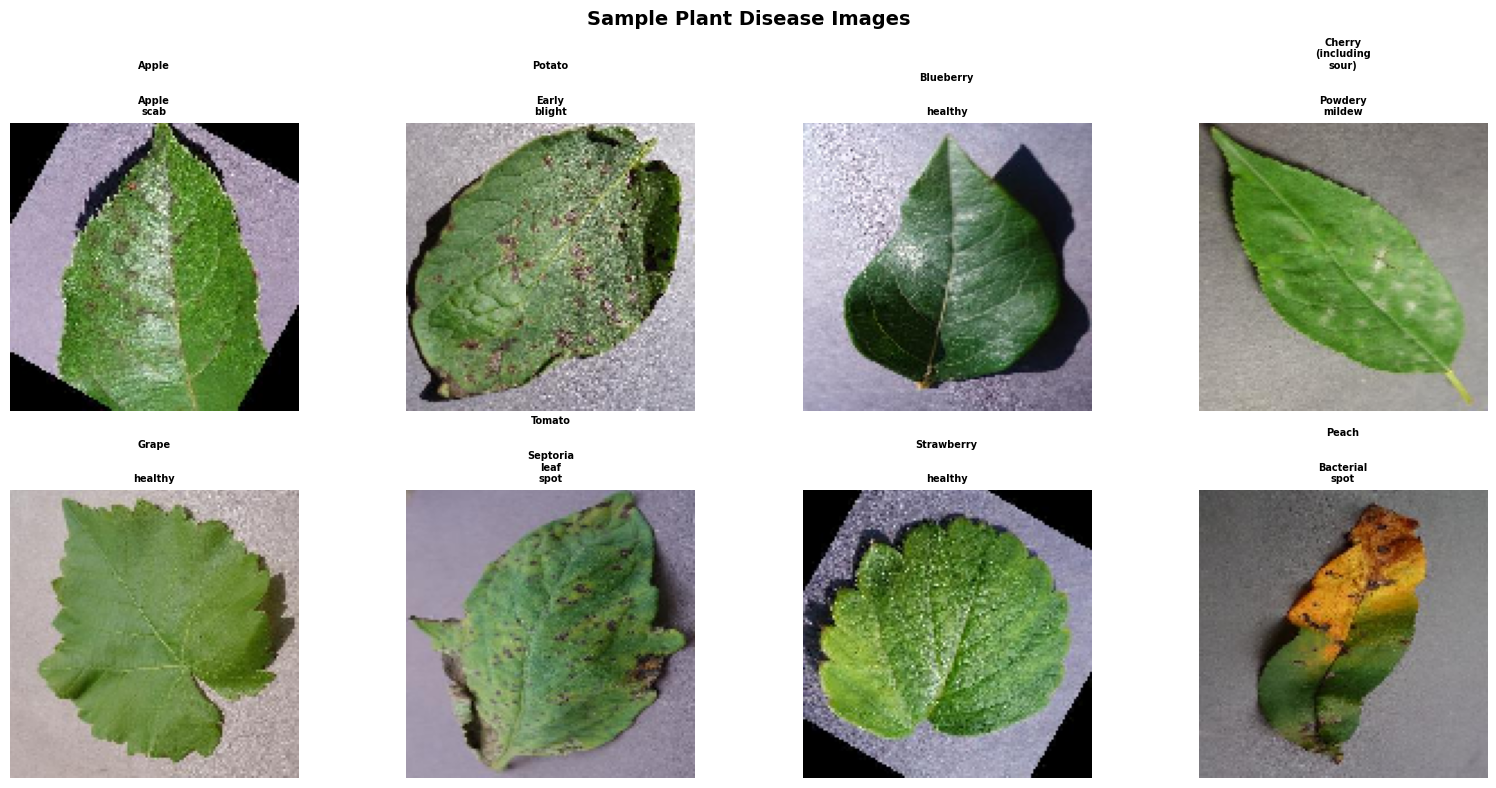

In [8]:
#Visualizing Dataset
import numpy as np

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# Show 1 sample from 8 random classes
import random
sample_classes = random.sample(CLASS_NAMES, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flat, sample_classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    fname   = os.listdir(cls_dir)[0]
    img     = load_img(os.path.join(cls_dir, fname), target_size=(128, 128))
    ax.imshow(img)
    ax.set_title(cls.replace('_', '\n'), fontsize=7, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Plant Disease Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
#Libraries Import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
#Data Pipeline

IMG_SIZE   = (128, 128)
BATCH_SIZE = 64        # larger batch — dataset is big
NUM_CLASSES = len(CLASS_NAMES)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
    # dataset is already augmented — keep it light
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

print('Classes:', NUM_CLASSES)
print('Training batches:  ', len(train_data))
print('Validation batches:', len(val_data))

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Classes: 38
Training batches:   1099
Validation batches: 275


In [11]:
#Building the model
tf.keras.backend.clear_session()

def build_plant_model(input_shape=(128, 128, 3), num_classes=38):
    """
    Sequential ConvNet for plant disease classification.
    38 classes — needs deeper network than binary problems.

    128 -> 64 -> 32 -> 16 -> 8  (via MaxPool x4)
    GlobalAveragePooling -> Dense(256) -> Dense(38, softmax)
    """
    model = Sequential([

        # Block 1: 128x128 -> 64x64
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(32, (3,3), padding='same'),   # double conv per block
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2: 64x64 -> 32x32
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3: 32x32 -> 16x16
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 4: 16x16 -> 8x8
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')

    ], name='PlantDisease_ConvNet')
    return model

model = build_plant_model(num_classes=NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "PlantDisease_ConvNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 128)    │             

 Total params: 660,550 (2.52 MB)

 Trainable params: 659,142 (2.51 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [12]:
# Force complete reset
import tensorflow as tf
tf.keras.backend.clear_session()
import gc
gc.collect()

model = build_plant_model(num_classes=NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Fresh model ready')
print(f'Parameters: {model.count_params():,}')

Fresh model ready
Parameters: 660,550


In [13]:
#Callback Definitions
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [14]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# Save best model automatically
checkpoint = ModelCheckpoint(
    filepath="/content/best_plant_disease_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Stop if model stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate if stuck
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

# Train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

# Save final model
model.save("/content/final_plant_disease_model.keras")

print("Model saved successfully!")

Epoch 1/30
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 421s 361ms/step - accuracy: 0.4420 - loss: 2.0059 - val_accuracy: 0.5417 - val_loss: 1.5324 - learning_rate: 1.0000e-04
Epoch 2/30
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 383s 349ms/step - accuracy: 0.6890 - loss: 1.0556 - val_accuracy: 0.5720 - val_loss: 1.4637 - learning_rate: 1.0000e-04
Epoch 3/30
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 384s 350ms/step - accuracy: 0.7774 - loss: 0.7469 - val_accuracy: 0.5950 - val_loss: 1.4203 - learning_rate: 1.0000e-04
Epoch 4/30
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 374s 340ms/step - accuracy: 0.8256 - loss: 0.5810 - val_accuracy: 0.6040 - val_loss: 1.3743 - learning_rate: 1.0000e-04
Epoch 5/30
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 380s 345ms/step - accuracy: 0.8534 - loss: 0.4825 - val_accuracy: 0.6178 - val_loss: 1.4215 - learning_rate: 1.0000e-04
Epoch 6/30
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 376s 342ms/step - accuracy: 0.8750 - loss: 0.4069 - val_accuracy: 0.7073 - val_loss: 0.9826 - learning_rate: 1.0000e-04
Epoch 7/30
1099/1099 ━━━━━━━

In [15]:
model.save("plant_disease_cnn.keras")

In [16]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/plant_disease_cnn.keras')

Mounted at /content/drive


**Results & Conclusion**

Validation Accuracy - ~78%
Number of Classes - 38
Training Images ~54,000+
Epochs Trained 30
Best Epoch 23

**What Worked**
- A custom CNN with multiple convolutional blocks successfully learned discriminative features across 38 plant disease categories.
- Data augmentation helped improve generalization by exposing the model to varied image transformations.
- BatchNormalization stabilised training significantly
- ReduceLROnPlateau automatically lowered the learning rate when validation performance plateaued, helping the model continue improving.
- EarlyStopping prevented unnecessary training and restored the best-performing weights.
- Dropout layers reduced overfitting and improved validation performance compared to a purely dense architecture.

**What Was Challenging**
- Overfitting was a recurring issue — train accuracy reached 96% while
val accuracy stayed around 78%
- The gap between train and val accuracy suggests the model is
memorising some training patterns rather than fully generalising
- Certain disease categories exhibited high intra-class variation and inter-class similarity, making generalization more difficult
- Training a CNN from scratch required careful tuning of learning rate, regularization, and architecture depth.

**Key Learnings **
- A learning rate that is too high causes val_accuracy to bounce and
never settle — reducing it stabilised training
- 38 classes is a hard problem for a ConvNet trained from scratch
- Data preprocessing and augmentation are as important as model architecture in image classification tasks.
- Learning-rate scheduling significantly impacts convergence and final model performance.
- Early stopping is an effective technique for preventing overtraining and preserving the best model.
- While custom CNNs can achieve strong results, transfer learning approaches such as EfficientNet and ResNet are likely to provide better generalization and higher validation accuracy with less training time
- Model evaluation should focus on validation performance and generalization rather than training accuracy alone.


